2. Instalación y configuración en Google Colab


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import os


3. Carga de datos desde la carpeta (mammals o raw-img) y partición en train/val/test

In [2]:
from google.colab import drive
drive.mount('/content/drive')

data_dir = "/content/drive/MyDrive/raw-img"
img_size = (128, 128)
batch_size = 32


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Usaremos image_dataset_from_directory para crear un dataset y luego lo separamos en tres subconjuntos: entrenamiento, validación y prueba.


In [3]:
dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

class_names = dataset.class_names
num_classes = len(class_names)
print("Clases:", class_names)

Found 14142 files belonging to 5 classes.
Clases: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina']


3.1 Separar en entrenamiento, validación y prueba
Haremos una partición aproximada 80% train, 10% val, 10% test:

dataset_size = 0
for _ in dataset:
    dataset_size += 1

train_size = int(0.8 * dataset_size)
val_size   = int(0.1 * dataset_size)
test_size  = dataset_size - train_size - val_size

train_ds = dataset.take(train_size)
rest = dataset.skip(train_size)
val_ds = rest.take(val_size)
test_ds = rest.skip(val_size)

print("Batches - train:", train_size, "val:", val_size, "test:", test_size)

In [4]:
# Tamaño total del dataset en batches
dataset_size = 0
for _ in dataset:
    dataset_size += 1

# Nuevas proporciones
train_size = int(0.8 * dataset_size)   # 80%
val_size   = int(0.1 * dataset_size)   # 10%
#test_size  = int(0.1 * dataset_size)   # 10%
test_size = dataset_size - train_size - val_size

# Particiones
train_ds = dataset.take(train_size)
rest = dataset.skip(train_size)

val_ds = rest.take(val_size)
test_ds = rest.skip(val_size)

print("Batches - train:", train_size,
      "val:", val_size,
      "test:", test_size)


Batches - train: 353 val: 44 test: 45


4. Preprocesamiento de datos
- Reescalamos píxeles a [0,1].
- Opcional: data augmentation ligero.
- Las etiquetas ya vienen codificadas como enteros; la capa final usará SparseCategoricalCrossentropy.


In [5]:
normalization_layer = layers.Rescaling(1./255)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

def prepare(ds, augment=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y),
                num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(AUTOTUNE)

train_ds_prep = prepare(train_ds, augment=True)
val_ds_prep   = prepare(val_ds, augment=False)
test_ds_prep  = prepare(test_ds, augment=False)

5. Construcción de la red neuronal convolucional

In [6]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Bloque 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Bloque 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Bloque 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Bloque 4 (más profundo para 128x128)
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Clasificación
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             

 Total params: 1,243,173 (4.74 MB)

 Trainable params: 1,241,253 (4.74 MB)

 Non-trainable params: 1,920 (7.50 KB)

5.1 Compilación

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

6.1 Entrenamiento

In [8]:
epochs = 10

history = model.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=epochs
)

Epoch 1/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 2246s 6s/step - accuracy: 0.4470 - loss: 1.4833 - val_accuracy: 0.1811 - val_loss: 2.9755
Epoch 2/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 2092s 6s/step - accuracy: 0.6237 - loss: 1.0016 - val_accuracy: 0.3913 - val_loss: 1.8721
Epoch 3/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 2110s 6s/step - accuracy: 0.6987 - loss: 0.8430 - val_accuracy: 0.4283 - val_loss: 1.8212
Epoch 4/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 2078s 6s/step - accuracy: 0.7347 - loss: 0.7355 - val_accuracy: 0.4567 - val_loss: 1.7177
Epoch 5/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 2075s 6s/step - accuracy: 0.7724 - loss: 0.6656 - val_accuracy: 0.4453 - val_loss: 1.7998
Epoch 6/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 2011s 6s/step - accuracy: 0.7988 - loss: 0.5864 - val_accuracy: 0.4517 - val_loss: 1.8081
Epoch 7/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 2009s 6s/step - accuracy: 0.8211 - loss: 0.5217 - val_accuracy: 0.4432 - val_loss: 1.9154
Epoch 8/10
353/353 ━━━━━━━━━━━━━━━━━━━━ 2008s 6s/step - accuracy: 0.8480 - loss: 0.4607 - 

6.2 Evaluación en el conjunto de prueba

In [9]:
test_loss, test_acc = model.evaluate(test_ds_prep)
print(f"Loss de prueba: {test_loss:.4f}")
print(f"Accuracy de prueba: {test_acc:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.5742 - loss: 1.3333
Loss de prueba: 1.3554
Accuracy de prueba: 0.5723


6.3 Curvas de entrenamiento

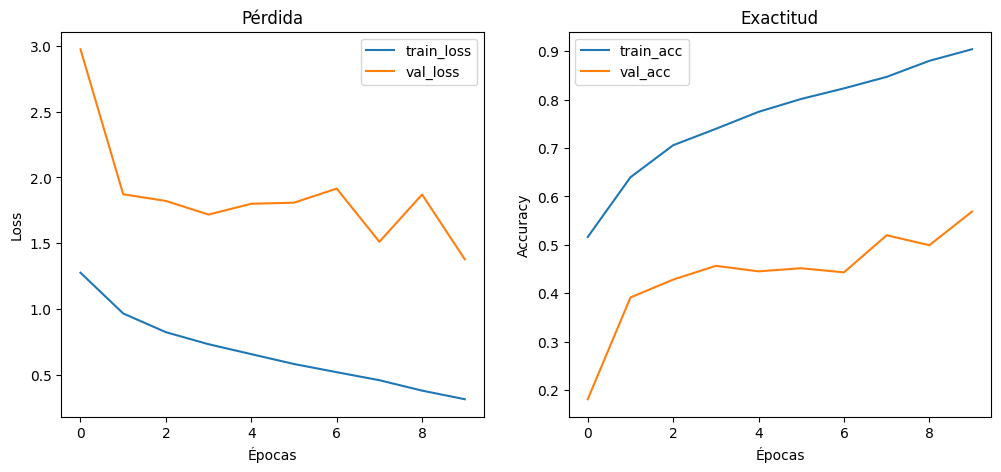

In [10]:
plt.figure(figsize=(12,5))

# Pérdida
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Pérdida")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

# Exactitud
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Exactitud")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Matriz de confusión para evaluar el clasificador

1. Obtener etiquetas verdaderas y predichas

In [11]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds_prep:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

2. Construir la matriz de confusión

In [12]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
cm

array([[223,  27,  16,  58, 171],
       [ 26, 112,   5,  18, 119],
       [ 17,   8,  76,   9,  58],
       [  6,   1,   0, 151,  44],
       [ 22,   0,   1,   9, 261]])

3. Visualizar la matriz de confusión

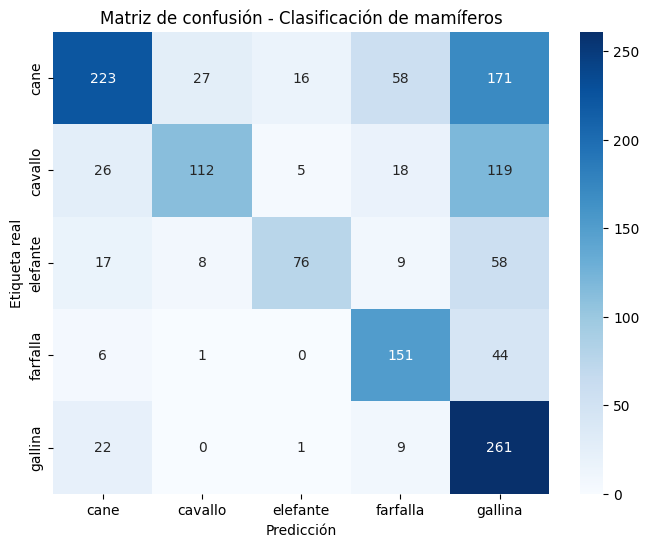

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión - Clasificación de mamíferos")
plt.show()

In [14]:
test_loss, test_acc = model.evaluate(test_ds_prep)

print(f"Pérdida en prueba: {test_loss:.4f}")
print(f"Exactitud en prueba: {test_acc:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.5742 - loss: 1.3333
Pérdida en prueba: 1.3554
Exactitud en prueba: 0.5723
